In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

# for Categorical Data

from sklearn.preprocessing import OneHotEncoder

# Train Test Split
from sklearn.model_selection import train_test_split

In [2]:
df_raw = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/Copy of For Data Processing.xlsx')

# Data Informatics

In [3]:
df_raw.head(3)

,PROJECT,CMD,BOD,No. of SBR,Region,Price
0,DLSU Dasmarinas Dorm Building 1,47,300,1,NCR,3.812580e+06
1,DLSU Dasmarinas Dorm Building 1,47,300,1,CALABARZON,4.002656e+06
2,DLSU Dasmarinas Dorm Building 1,47,300,1,MIMAROPA,4.592669e+06


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PROJECT     273 non-null    object 
 1   CMD         273 non-null    int64  
 2   BOD         273 non-null    int64  
 3   No. of SBR  273 non-null    int64  
 4   Region      273 non-null    object 
 5   Price       273 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 12.9+ KB


In [5]:
df_raw.describe(include='all')

,PROJECT,CMD,BOD,No. of SBR,Region,Price
count,273,273.000000,273.000000,273.000000,273,2.730000e+02
unique,52,NaN,NaN,NaN,7,NaN
top,ASEANA PLAZA PHASE 1,NaN,NaN,NaN,NCR,NaN
freq,15,NaN,NaN,NaN,39,NaN
mean,NaN,345.256410,437.179487,1.717949,NaN,6.217698e+06
std,NaN,351.318598,172.674977,0.450825,NaN,1.921513e+06
min,NaN,30.000000,300.000000,1.000000,NaN,3.698804e+06
25%,NaN,100.000000,300.000000,1.000000,NaN,4.822336e+06
50%,NaN,180.000000,400.000000,2.000000,NaN,5.669719e+06
75%,NaN,570.000000,500.000000,2.000000,NaN,7.121114e+06


In [6]:
df_raw.isnull().sum()

,0
PROJECT,0
CMD,0
BOD,0
No. of SBR,0
Region,0
Price,0


About the data:

- The data is composed of various project proposals from 2025 to 2026.


- The data consists of flow rate in cubic meter per day (CMD), Biological Oxygen Demand (BOD), Number of Sequencing Batch Reactor (SBR), Region, Civil Works, Design Instruction, Level of Tanks, and Price. These variables were obtained from the proposed technical and commercial designs.

**Data Features:**

1. Flow rate -  The client's proposed plant capacity in cubic meters per day.
2. BOD - The primary design metric for tank sizing and design configuration.
3. No. of SBR - Dictates the number of cycles per day, the number of SBR usually depends on the capacity of the plant and the proposed area.
4. Region - Proposed place of the plant, important for
7. Price of the Design

## Dropping Columns

In [7]:
df_raw.columns

Index(['PROJECT', 'CMD', 'BOD', 'No. of SBR', 'Region', 'Price'], dtype='object')

In [8]:
# Dropping Project Titles

df_raw = df_raw.drop('PROJECT', axis=1)

In [9]:
df_raw.head(3)

,CMD,BOD,No. of SBR,Region,Price
0,47,300,1,NCR,3.812580e+06
1,47,300,1,CALABARZON,4.002656e+06
2,47,300,1,MIMAROPA,4.592669e+06


## Correlation


Text(0.5, 1.0, 'Correlation Matrix')

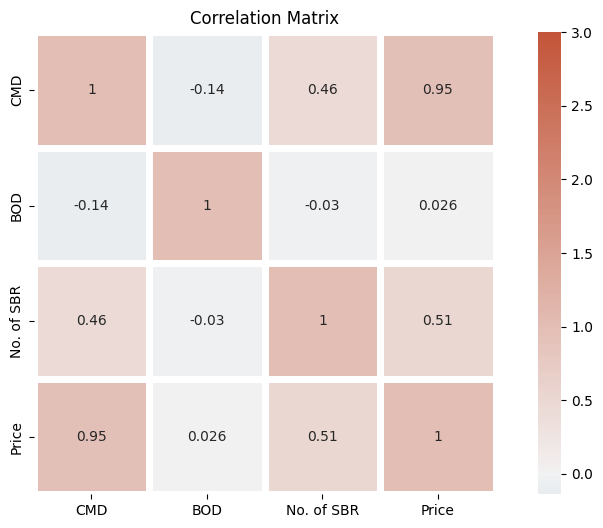

In [10]:
categorical_col = ['Region']

for_correlation = df_raw.drop(categorical_col, axis=1)

plt.subplots(figsize=(11,6))
sns.heatmap(for_correlation.corr(),
            vmax=3,
            center=0,
            square=True,
            linewidth=5,
            cmap = sns.diverging_palette(230, 20, as_cmap=True),
            annot=True
            )
plt.title('Correlation Matrix')

The correlation matrix makes logical sense because flow rre shares an extremely positive correlation of 0.95 with price. This confirms that higher waste water inflow directly affect the cost.

Furthermore, the Number of SBR displays a moderate positive correlation with both CMD (0.46) and Price (0.51) because the reactor count is highly dependent on land availability and operational cycles; while a single SBR tank might suffice for 4 cycles a day under ideal conditions, a restricted site area forces engineers to deploy multiple smaller SBR units to keep individual tank sizes structurally manageable without over-dimensioning them.

# Univariate Analysis

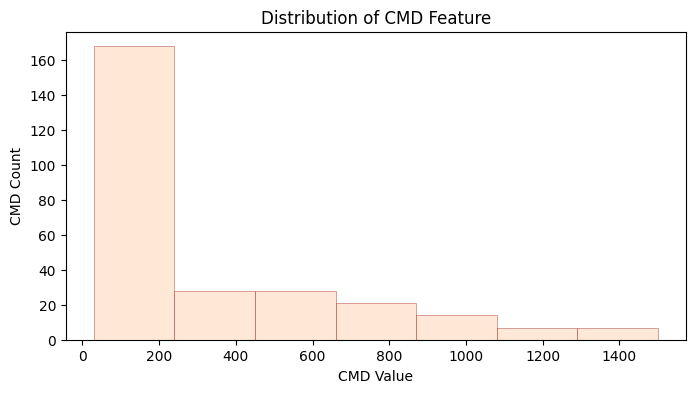

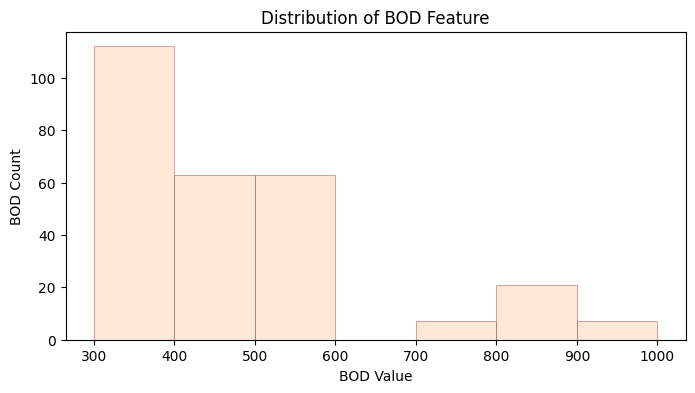

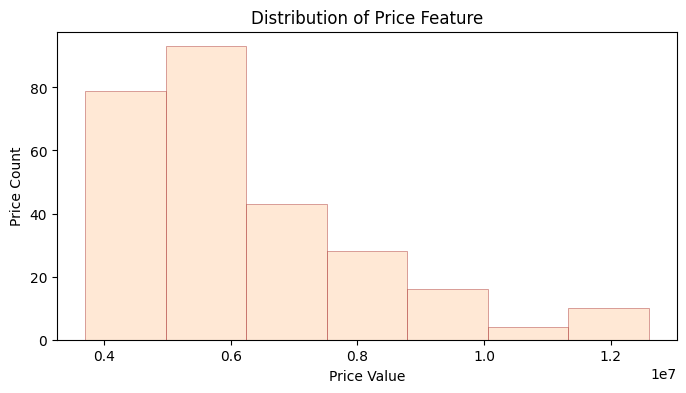

In [11]:
numerical_cols = ['CMD',
                  'BOD',
                  'Price']

for col in numerical_cols:

  fig, ax = plt.subplots(figsize=(8,4))

  ax.hist(df_raw[col], bins=7,
    color='peachpuff',
    linewidth=0.5,
    alpha=0.6,
    edgecolor='brown',
    )
  plt.ylabel(f'{col} Count')
  plt.xlabel(f'{col} Value')
  plt.title(f'Distribution of {col} Feature')
  plt.show()



1.   **CMD Feature**
  - Most proposed projects fall within the 50 - 200 CMD range, as these industries typically serve very minimal flowrate. This explains why the distribution heavily peaks in that initial interval.

  - On the other hand, CMD values exceeding 200 represent larger projects; for example, major hotels with high demans (commercial kitchens and septage), while really high CMD values correspond to large-scale residential places.

2.   **Biological Oxygen Demand (BOD) Feature**

 - This distribution reflects ifferent wastewater profiles from various projects. The usual peak betweek 300 and 500 ppm typically represents dometic waste. Commercial spaces generally fall into the 600-800 ppm (due to high kitchen waste).

3. **Price**

- The distribution of Price aligns perfectly with the expectations because of the correlation matrix. Price shows a positive correlation with CMD (r = 0.95) because it is highly skewed toward smaller-scale projects.


## Outlier Detection

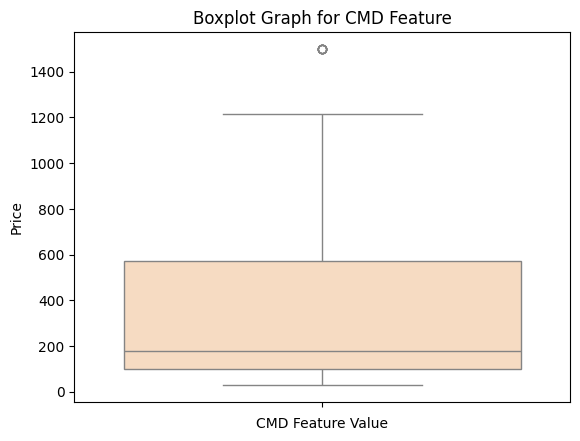

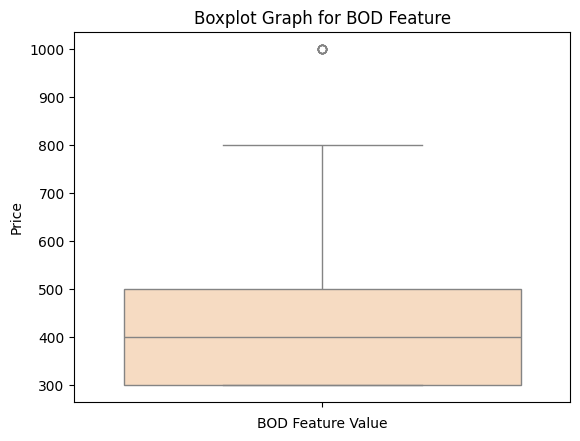

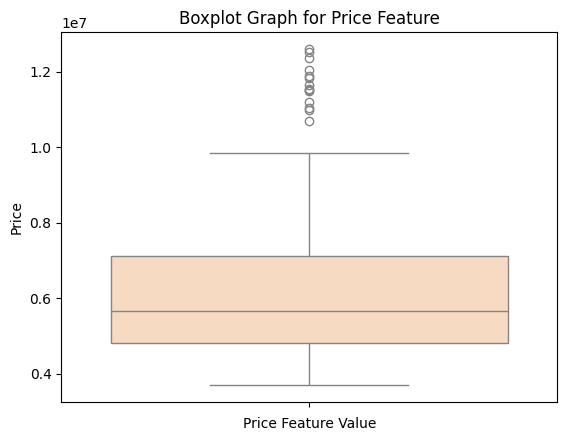

In [12]:
for_outlier_checking = ['CMD','BOD', 'Price']


for col in for_outlier_checking:

  sns.boxplot(y=df_raw[col],
              color='peachpuff',
              )
  plt.figsize=(8.4)
  plt.title(f'Boxplot Graph for {col} Feature')
  plt.xlabel(f'{col} Feature Value')
  plt.ylabel('Price')
  plt.show()


In [13]:
# Percentage of Outliers

for col in for_outlier_checking:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)

    IQR = q3 - q1

    upper_bound = q3 + 1.5 * IQR
    lower_bound = q1 - 1.5 * IQR

    outliers = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)]
    percentage_outliers = (len(outliers) / len(df_raw)) * 100
    print(f"Percentage of outliers in '{col}': {percentage_outliers:.2f}%")

Percentage of outliers in 'CMD': 2.56%
Percentage of outliers in 'BOD': 2.56%
Percentage of outliers in 'Price': 5.13%


In [14]:
display(outliers)
display(df_raw[df_raw['CMD'] > 1000])

,CMD,BOD,No. of SBR,Region,Price
154,1216,400,2,NCR,1.069147e+07
155,1216,400,2,CALABARZON,1.097651e+07
156,1216,400,2,MIMAROPA,1.163355e+07
157,1216,400,2,CENTRAL LUZON,1.103749e+07
158,1216,400,2,NORTH LUZON,1.119881e+07
159,1216,400,2,VISAYAS,1.150281e+07
160,1216,400,2,MINDANAO,1.149348e+07
252,1500,400,2,NCR,1.152902e+07
253,1500,400,2,CALABARZON,1.181708e+07
254,1500,400,2,MIMAROPA,1.260058e+07


,CMD,BOD,No. of SBR,Region,Price
154,1216,400,2,NCR,1.069147e+07
155,1216,400,2,CALABARZON,1.097651e+07
156,1216,400,2,MIMAROPA,1.163355e+07
157,1216,400,2,CENTRAL LUZON,1.103749e+07
158,1216,400,2,NORTH LUZON,1.119881e+07
159,1216,400,2,VISAYAS,1.150281e+07
160,1216,400,2,MINDANAO,1.149348e+07
252,1500,400,2,NCR,1.152902e+07
253,1500,400,2,CALABARZON,1.181708e+07
254,1500,400,2,MIMAROPA,1.260058e+07


- The right-skewed distribution indicates that high-cost projects are not statistical outliers; rather, our current dataset is primarily concentrated on small-scale developments.


---

**Outlier Treatment**

- Given the data constraints at higher capacity levels and the high frequency of budgetary inquiries from small-scale developments, the prediction of the developed models will be intentionally focused on small-scale projects. Therefore,dropping the high-cost entries is crucial if we want higher accuracy for small market estimates.




In [15]:
df_raw[df_raw['BOD'] >=1000]

,CMD,BOD,No. of SBR,Region,Price
238,175,1000,1,NCR,5.488990e+06
239,175,1000,1,CALABARZON,5.685843e+06
240,175,1000,1,MIMAROPA,6.275856e+06
241,175,1000,1,CENTRAL LUZON,5.740794e+06
242,175,1000,1,NORTH LUZON,5.899809e+06
243,175,1000,1,VISAYAS,6.166909e+06
244,175,1000,1,MINDANAO,6.159133e+06


In [16]:
# Dropping CMD > 1000

df_raw = df_raw[df_raw['CMD'] <= 1000]

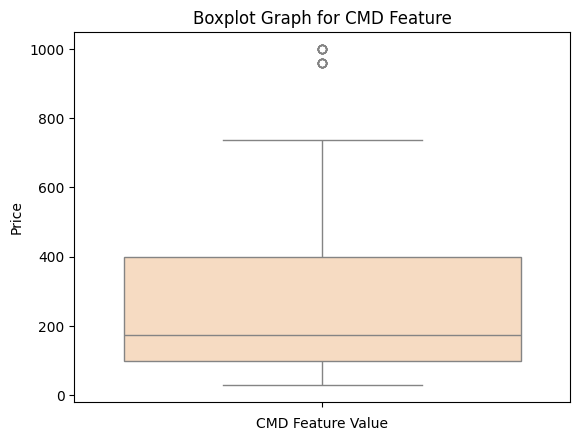

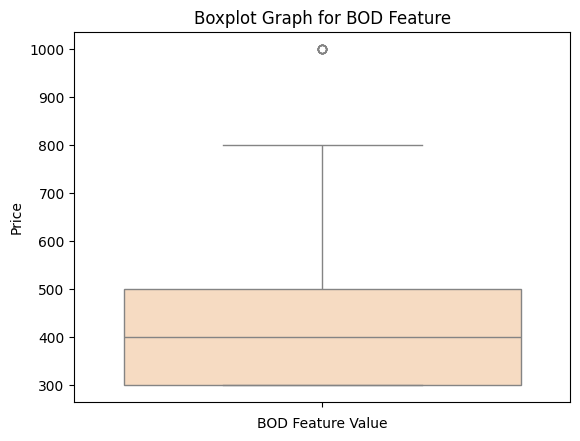

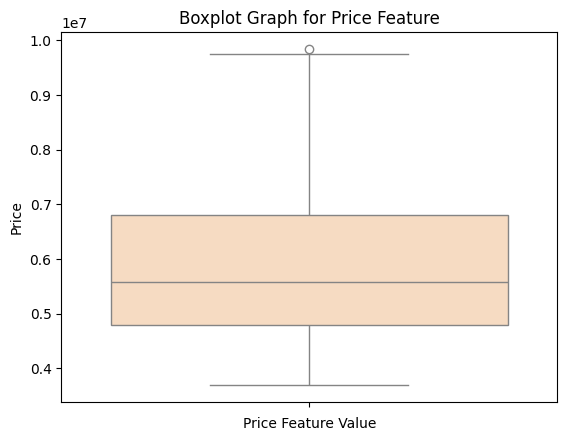

In [17]:
# Rechecking the Outliers

for col in for_outlier_checking:

  sns.boxplot(y=df_raw[col],
              color='peachpuff',
              )
  plt.figsize=(8.4)
  plt.title(f'Boxplot Graph for {col} Feature')
  plt.xlabel(f'{col} Feature Value')
  plt.ylabel('Price')
  plt.show()

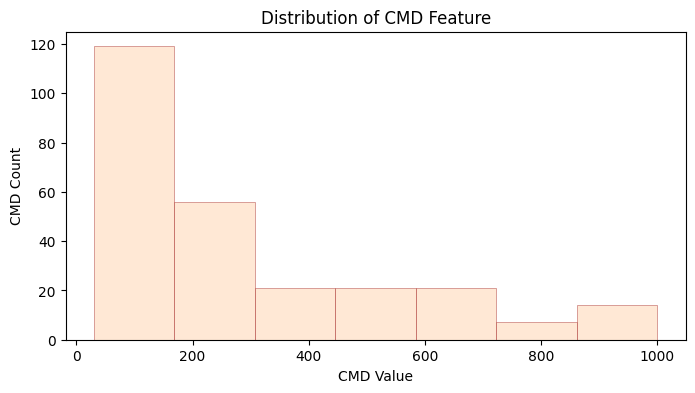

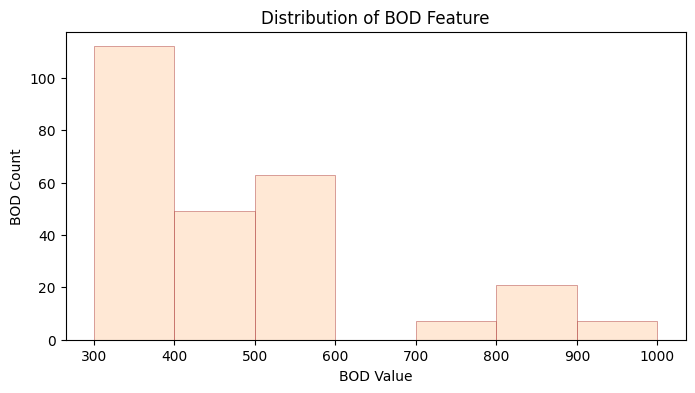

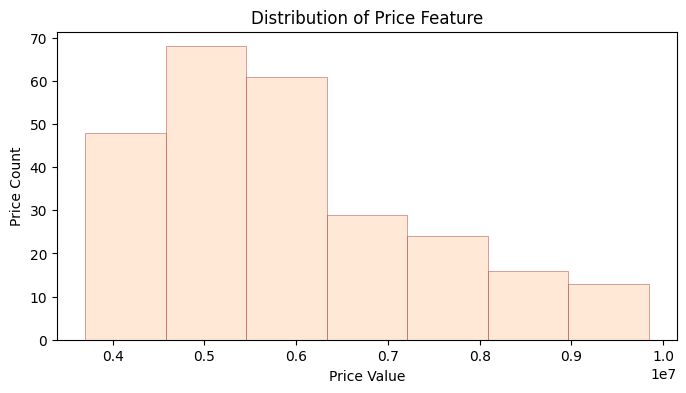

In [18]:
for col in numerical_cols:

  fig, ax = plt.subplots(figsize=(8,4))

  ax.hist(df_raw[col], bins=7,
    color='peachpuff',
    linewidth=0.5,
    alpha=0.6,
    edgecolor='brown',
    )
  plt.ylabel(f'{col} Count')
  plt.xlabel(f'{col} Value')
  plt.title(f'Distribution of {col} Feature')
  plt.show()

Feature Engineering

In [19]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

region_encoded = encoder.fit_transform(df_raw[['Region']])

region_df = pd.DataFrame(region_encoded, columns=encoder.get_feature_names_out(['Region']))

# Concatenate
df_processed = pd.concat([df_raw.drop('Region', axis=1), region_df], axis=1)

print("DataFrame after one-hot encoding 'Region' using scikit-learn:")
display(df_processed.head())

# Dropping NAN

df_processed = df_processed.dropna()

DataFrame after one-hot encoding 'Region' using scikit-learn:


,CMD,BOD,No. of SBR,Price,Region_CALABARZON,Region_CENTRAL LUZON,Region_MIMAROPA,Region_MINDANAO,Region_NCR,Region_NORTH LUZON,Region_VISAYAS
0,47.0,300.0,1.0,3.812580e+06,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,47.0,300.0,1.0,4.002656e+06,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,47.0,300.0,1.0,4.592669e+06,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,47.0,300.0,1.0,4.057607e+06,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,47.0,300.0,1.0,4.216621e+06,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 245 entries, 0 to 251
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CMD                   245 non-null    float64
 1   BOD                   245 non-null    float64
 2   No. of SBR            245 non-null    float64
 3   Price                 245 non-null    float64
 4   Region_CALABARZON     245 non-null    float64
 5   Region_CENTRAL LUZON  245 non-null    float64
 6   Region_MIMAROPA       245 non-null    float64
 7   Region_MINDANAO       245 non-null    float64
 8   Region_NCR            245 non-null    float64
 9   Region_NORTH LUZON    245 non-null    float64
 10  Region_VISAYAS        245 non-null    float64
dtypes: float64(11)
memory usage: 23.0 KB


In [21]:
# Fixing the order of the columns
columns = df_processed.columns.tolist()

if 'Price' in columns:
    columns.remove('Price')

columns.append('Price')

df_final = df_processed[columns]

print("DataFrame with 'Price' as the last column:")
display(df_final.head())

DataFrame with 'Price' as the last column:


,CMD,BOD,No. of SBR,Region_CALABARZON,Region_CENTRAL LUZON,Region_MIMAROPA,Region_MINDANAO,Region_NCR,Region_NORTH LUZON,Region_VISAYAS,Price
0,47.0,300.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.812580e+06
1,47.0,300.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.002656e+06
2,47.0,300.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.592669e+06
3,47.0,300.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.057607e+06
4,47.0,300.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.216621e+06


In [22]:
output_path = '/content/drive/MyDrive/Cost Prediction/WORK/processed_data.xlsx'
df_final.to_excel(output_path, index=False)
print(f"Processed data saved to {output_path}")

Processed data saved to /content/drive/MyDrive/Cost Prediction/WORK/processed_data.xlsx


# Train Test Split

In [23]:

X = df_final.drop(columns=['Price'])
y = df_final['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.80,
    random_state=42
)


# --- VERIFICATION PRINTS ---
print("--- Data Split Structure Completed ---")
print(f"Total Original Real Pool: {len(df_final)} rows")
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

# Saving the train test splits

X_train_path = '/content/drive/MyDrive/Cost Prediction/WORK/X_train_cost_prediction.xlsx'
X_train.to_excel(X_train_path, index=False)

X_test_path = '/content/drive/MyDrive/Cost Prediction/WORK/X_test_cost_prediction.xlsx'
X_test.to_excel(X_test_path, index=False)

y_train_path = '/content/drive/MyDrive/Cost Prediction/WORK/y_train_cost_prediction.xlsx'
y_train.to_excel(y_train_path, index=False)

y_test_path = '/content/drive/MyDrive/Cost Prediction/WORK/y_test_cost_prediction.xlsx'
y_test.to_excel(y_test_path, index=False)

--- Data Split Structure Completed ---
Total Original Real Pool: 245 rows
X_train: (196, 10)
X_test: (49, 10)
y_train: (196,)
y_test: (49,)
